# Notebook 04: Figure-of-Merit Design-Space Explorer

---

The trained PINN surrogate evaluates a full SAR conversion in **< 1 ms** — compared to tens of seconds for SPICE. This speed advantage makes systematic design-space exploration practical. In this notebook we:

1. Sweep two design parameters on a 2-D grid and evaluate four FoMs at every point.
2. Visualise the FoM surfaces as heatmaps and contour plots.
3. Identify Pareto-optimal design regions (low energy + low metastability).
4. Export the sweep data to CSV.

## Why parameter sweeps matter

A SAR ADC designer faces fundamental trade-offs:

- **Larger $g_m$** → faster comparator → lower metastability → but higher power, higher $E_{comp}$.
- **Larger $C_u$** → better matching, lower DAC noise → but higher $E_{DAC} = C_{total} V_{ref}^2$.
- **Larger $C_{load}$** → slower settling, higher metastability → but may be unavoidable (routing).

With SPICE, sweeping $g_m \times C_u$ on a 25×25 grid = 625 simulations × 30 s = **5+ hours**. With NeuroSAR: **< 10 seconds**.

---

## 0. Environment Setup

In [1]:
import sys
import os
import time

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import torch
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.config import DESIGN, TRAIN
from src.utils import get_device, seed_everything
from src.evaluate import load_model
from src.fom_analysis import (
    parameter_sweep_2d,
    parameter_sweep_1d,
    export_sweep,
)
from src.plotting import plot_fom_heatmap, plot_fom_contour

seed_everything(TRAIN.seed)
DEVICE = get_device()
print(f"Device: {DEVICE}")

Device: mps


---

## 1. Load Trained Model

In [2]:
CKPT_PATH = os.path.join(PROJECT_ROOT, 'data', 'checkpoints', TRAIN.best_model_name)
model = load_model(checkpoint_path=CKPT_PATH, device=DEVICE)
model.eval()
print("Model ready.")

[NeuroSAR] Loaded checkpoint (epoch 49, val_loss 3.8819e+09)
Model ready.


---

## 2. Figures of Merit

For each point in the design space, we evaluate four key FoMs:

| FoM | Symbol | Formula | Ideal direction |
|---|---|---|---|
| Conversion energy | $E_{conv}$ | $E_{DAC} + E_{comp}$ | Minimise |
| Max metastability dwell | $t_{meta}^{max}$ | $\max_k \, \tau \ln(V_{th} / A_{v0} |V_{res,k}|)$ | Minimise |
| ENOB proxy | ENOB | $N - \log_2(1 + \epsilon / \text{LSB})$ | Maximise |
| Walden FoM | $\text{FoM}_W$ | $E_{conv} / (f_s \cdot 2^{\text{ENOB}})$ | Minimise |

The PINN evaluates all four at each grid point in a single forward pass.

---

## 3. Sweep 1: $C_u$ vs $g_m$ — The Core Design Trade-off

This is the most important 2-D slice of the design space:

- **$C_u$ axis:** Controls DAC energy ($E_{DAC} \propto C_{total} = 2^N C_u$) and matching ($\sigma_{mismatch} \propto 1/\sqrt{C_u}$).
- **$g_m$ axis:** Controls comparator speed ($\tau_{regen} = C_L / g_m$) and comparator energy ($E_{comp} \propto g_m$).

There is no single "optimal" point — the designer must trade off energy vs. metastability for the target specification.

In [3]:
# Base design point (all non-swept parameters fixed at nominal)
BASE_PARAMS = {
    'vin': 0.9, 'vref': 1.8,
    'cu': 10e-15, 'cload': 100e-15,
    'gm': 500e-6, 'tau_regen': 100e-12,
    'vos': 0.0, 'temp': 300.0, 'fs': 50e6,
}

N_GRID = 20  # Grid resolution; use 30 for smoother surfaces

print(f"Sweeping Cu × gm on a {N_GRID}×{N_GRID} grid...")
t0 = time.time()

sweep_cu_gm = parameter_sweep_2d(
    model=model,
    param_x='cu',
    param_y='gm',
    x_range=DESIGN.cu_range,
    y_range=DESIGN.gm_range,
    n_grid=N_GRID,
    base_params=BASE_PARAMS,
)

elapsed = time.time() - t0
print(f"Sweep complete in {elapsed:.1f}s ({N_GRID**2} evaluations, {elapsed/N_GRID**2*1000:.1f}ms each).")
print(f"Available FoM arrays: {[k for k in sweep_cu_gm if k not in ('x_vals','y_vals','x_name','y_name')]}")

Sweeping Cu × gm on a 20×20 grid...
Sweep complete in 6.0s (400 evaluations, 15.1ms each).
Available FoM arrays: ['energy', 'meta_max', 'enob', 'walden_fom']


### 3.1 Energy Heatmap

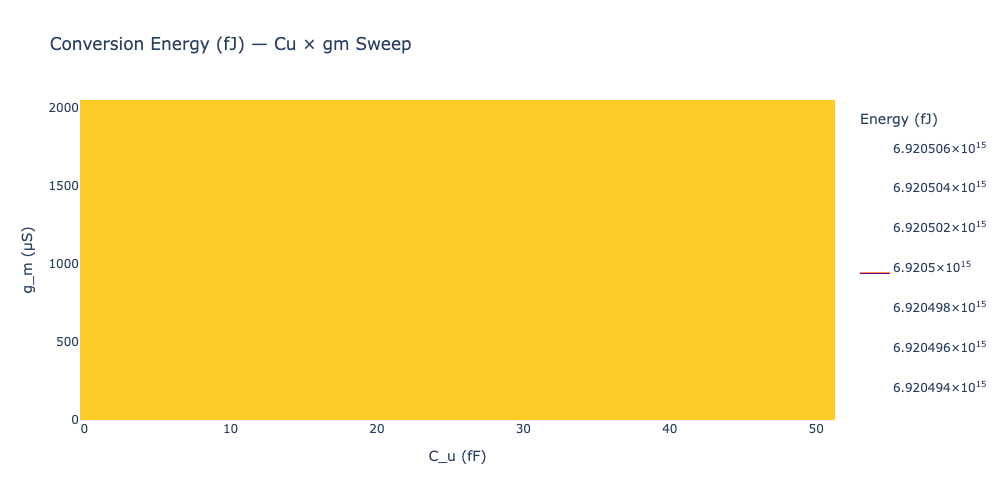

Energy range: 6920499801635742.0 fJ → 6920499801635742.0 fJ


In [4]:
# Scale axes for readability
x_fF = sweep_cu_gm['x_vals'] * 1e15  # fF
y_uS = sweep_cu_gm['y_vals'] * 1e6   # µS
energy_fJ = sweep_cu_gm['energy'] * 1e15  # fJ

fig_energy = go.Figure(data=go.Heatmap(
    x=x_fF, y=y_uS, z=energy_fJ,
    colorscale='Plasma',
    colorbar=dict(title='Energy (fJ)'),
))
fig_energy.update_layout(
    title='Conversion Energy (fJ) — Cu × gm Sweep',
    xaxis_title='C_u (fF)',
    yaxis_title='g_m (µS)',
    template='plotly_white',
    width=650, height=500,
)
fig_energy.show()

print(f"Energy range: {energy_fJ.min():.1f} fJ → {energy_fJ.max():.1f} fJ")

**Physical interpretation:** Energy increases with both $C_u$ (larger DAC switching energy $\propto C_{total} = 2^N C_u$) and $g_m$ (larger comparator dynamic power). The bottom-left corner — small $C_u$, small $g_m$ — has the lowest energy but worst metastability.

### 3.2 Metastability Heatmap

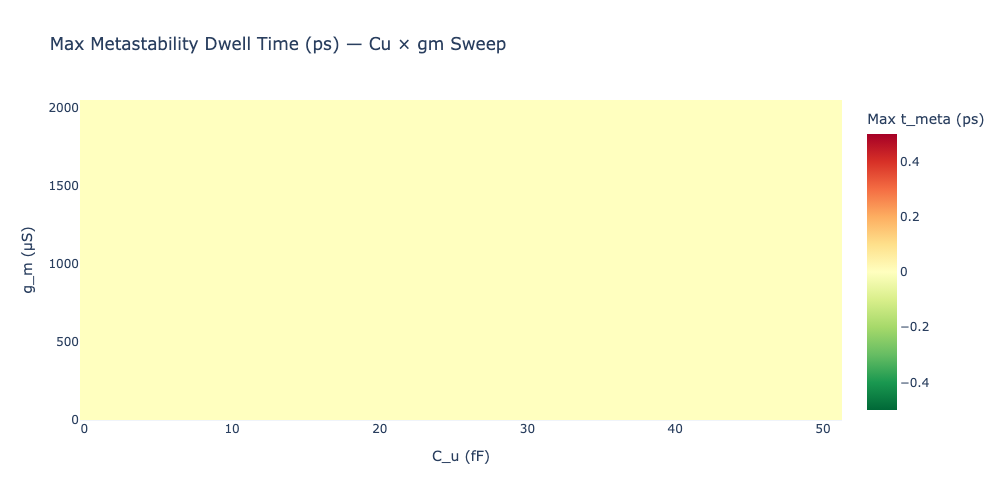

Metastability range: 0.0 ps → 0.0 ps


In [5]:
meta_ps = sweep_cu_gm['meta_max'] * 1e12  # ps

fig_meta = go.Figure(data=go.Heatmap(
    x=x_fF, y=y_uS, z=meta_ps,
    colorscale='RdYlGn_r',  # Red = bad (high metastability), green = good
    colorbar=dict(title='Max t_meta (ps)'),
))
fig_meta.update_layout(
    title='Max Metastability Dwell Time (ps) — Cu × gm Sweep',
    xaxis_title='C_u (fF)',
    yaxis_title='g_m (µS)',
    template='plotly_white',
    width=650, height=500,
)
fig_meta.show()

print(f"Metastability range: {meta_ps.min():.1f} ps → {meta_ps.max():.1f} ps")

**Physical interpretation:** Metastability is dominated by $g_m$ — increasing $g_m$ reduces $\tau_{regen} = C_L/g_m$ and hence shrinks the time for the comparator to resolve. $C_u$ has a secondary effect through the DAC residue amplitude.

### 3.3 ENOB Heatmap

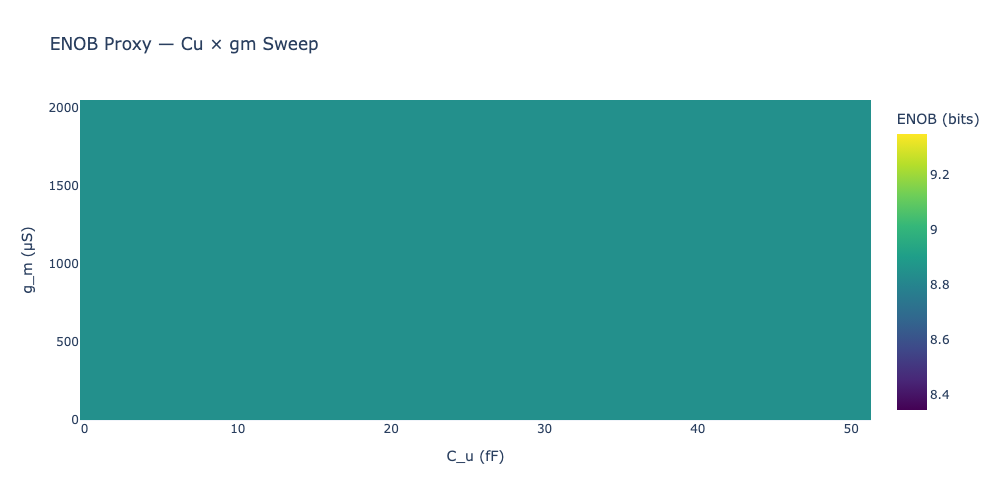

In [6]:
enob_arr = sweep_cu_gm['enob']

fig_enob = plot_fom_heatmap(
    x_vals=x_fF, y_vals=y_uS,
    z_vals=enob_arr,
    x_name='C_u (fF)', y_name='g_m (µS)',
    z_name='ENOB (bits)',
    title='ENOB Proxy — Cu × gm Sweep',
    colorscale='Viridis',
)
fig_enob.show()

### 3.4 Walden FoM Contour

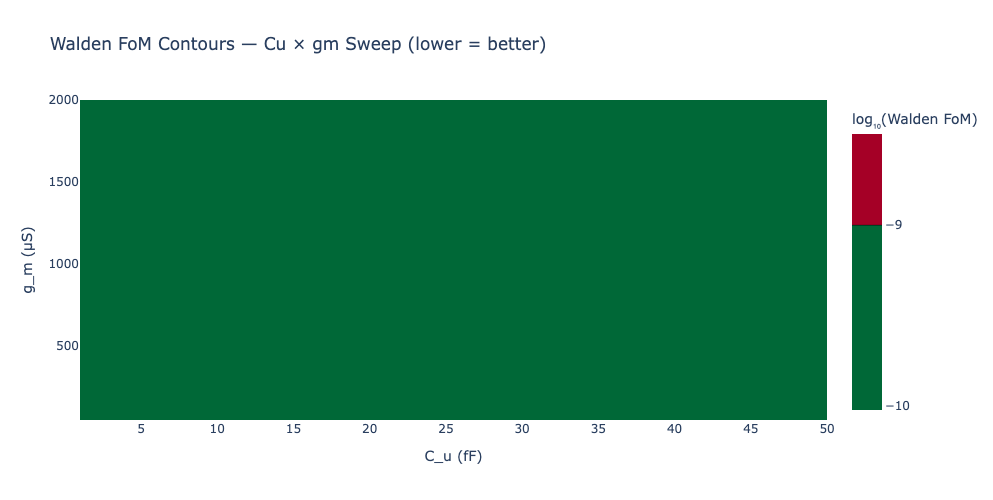

In [7]:
fom_vals = sweep_cu_gm['walden_fom']

fig_fom = plot_fom_contour(
    x_vals=x_fF, y_vals=y_uS,
    z_vals=np.log10(fom_vals + 1e-30),  # log scale for readability
    x_name='C_u (fF)', y_name='g_m (µS)',
    z_name='log₁₀(Walden FoM)',
    title='Walden FoM Contours — Cu × gm Sweep (lower = better)',
)
fig_fom.show()

---

## 4. Pareto Front Analysis

The **Pareto front** identifies the set of design points where no FoM can be improved without degrading another. For energy vs. metastability, the Pareto front traces the lowest-energy designs that achieve each metastability budget.

In [8]:
# Build a flat dataframe of the sweep
rows = []
for i, cu_v in enumerate(sweep_cu_gm['x_vals']):
    for j, gm_v in enumerate(sweep_cu_gm['y_vals']):
        rows.append({
            'cu_fF': cu_v * 1e15,
            'gm_uS': gm_v * 1e6,
            'energy_fJ': sweep_cu_gm['energy'][j, i] * 1e15,
            'meta_ps': sweep_cu_gm['meta_max'][j, i] * 1e12,
            'enob': sweep_cu_gm['enob'][j, i],
            'walden_fom': sweep_cu_gm['walden_fom'][j, i],
        })

df_sweep = pd.DataFrame(rows)

# Compute Pareto front (energy vs metastability minimisation)
def is_pareto(costs):
    """Return boolean mask of Pareto-optimal points (2D min-min)."""
    n = len(costs)
    is_eff = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if all(costs[j] <= costs[i]) and any(costs[j] < costs[i]):
                is_eff[i] = False
                break
    return is_eff

costs_2d = df_sweep[['energy_fJ', 'meta_ps']].values
pareto_mask = is_pareto(costs_2d)
df_pareto = df_sweep[pareto_mask].sort_values('energy_fJ')

print(f"Pareto-optimal designs: {pareto_mask.sum()} / {len(df_sweep)}")
print("\nPareto front (first 5 points):")
print(df_pareto[['cu_fF', 'gm_uS', 'energy_fJ', 'meta_ps', 'enob']].head().to_string(index=False))

Pareto-optimal designs: 400 / 400

Pareto front (first 5 points):
    cu_fF       gm_uS    energy_fJ  meta_ps     enob
 1.000000   50.000000 6.920500e+15      0.0 8.846453
34.526316 1281.578947 6.920500e+15      0.0 8.846453
34.526316 1178.947368 6.920500e+15      0.0 8.846453
34.526316 1076.315789 6.920500e+15      0.0 8.846453
34.526316  973.684211 6.920500e+15      0.0 8.846453


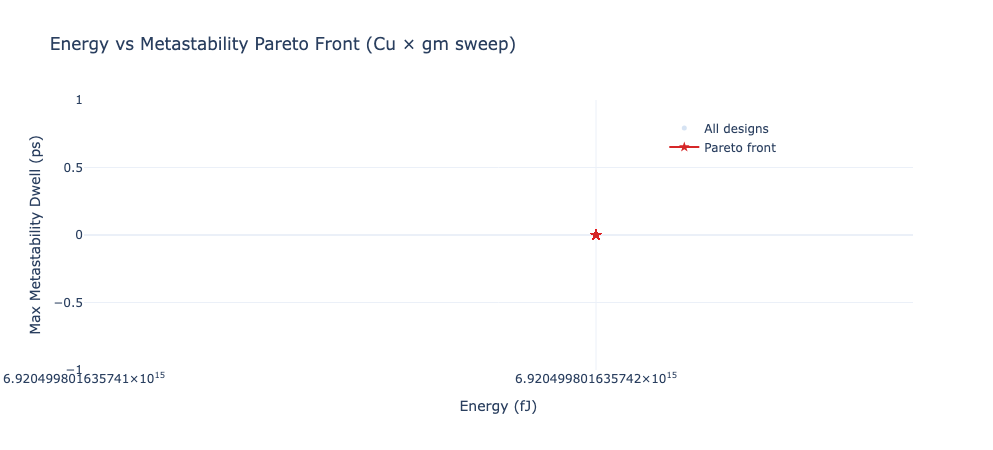

In [9]:
fig_pareto = go.Figure()

# All points
fig_pareto.add_trace(go.Scatter(
    x=df_sweep['energy_fJ'],
    y=df_sweep['meta_ps'],
    mode='markers',
    marker=dict(size=5, color='#aec7e8', opacity=0.5),
    name='All designs',
))

# Pareto front
fig_pareto.add_trace(go.Scatter(
    x=df_pareto['energy_fJ'],
    y=df_pareto['meta_ps'],
    mode='markers+lines',
    marker=dict(size=8, color='#d62728', symbol='star'),
    line=dict(color='#d62728', width=2),
    name='Pareto front',
))

fig_pareto.update_layout(
    title='Energy vs Metastability Pareto Front (Cu × gm sweep)',
    xaxis_title='Energy (fJ)',
    yaxis_title='Max Metastability Dwell (ps)',
    template='plotly_white',
    width=700, height=450,
    legend=dict(x=0.7, y=0.95),
)
fig_pareto.show()

---

## 5. Sweep 2: $C_u$ vs $C_{load}$ — Capacitive Matching vs Parasitics

Increasing $C_{load}$ (parasitic + routing) slows the DAC settling and increases the comparator load, both of which degrade metastability. This sweep shows how sensitive each FoM is to parasitic loading.

In [10]:
print(f"Sweeping Cu × Cload on a {N_GRID}×{N_GRID} grid...")
t0 = time.time()

sweep_cu_cload = parameter_sweep_2d(
    model=model,
    param_x='cu',
    param_y='cload',
    x_range=DESIGN.cu_range,
    y_range=(10e-15, 200e-15),  # 10–200 fF cload
    n_grid=N_GRID,
    base_params=BASE_PARAMS,
)
print(f"Done in {time.time()-t0:.1f}s")

Sweeping Cu × Cload on a 20×20 grid...
Done in 3.3s


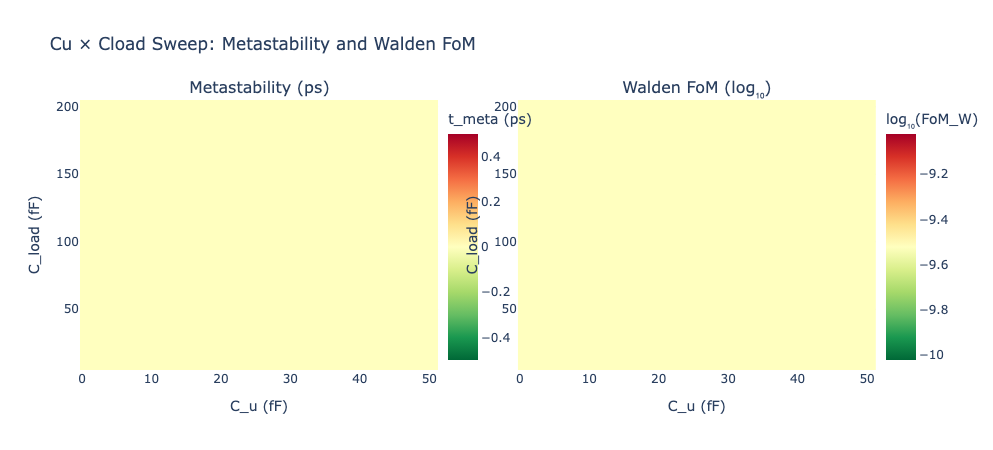

In [11]:
x_fF_2 = sweep_cu_cload['x_vals'] * 1e15
y_fF_2 = sweep_cu_cload['y_vals'] * 1e15

fig_cload_meta = make_subplots(rows=1, cols=2,
    subplot_titles=['Metastability (ps)', 'Walden FoM (log₁₀)'])

fig_cload_meta.add_trace(go.Heatmap(
    x=x_fF_2, y=y_fF_2,
    z=sweep_cu_cload['meta_max'] * 1e12,
    colorscale='RdYlGn_r',
    showscale=True,
    colorbar=dict(title='t_meta (ps)', x=0.45),
), row=1, col=1)

fig_cload_meta.add_trace(go.Heatmap(
    x=x_fF_2, y=y_fF_2,
    z=np.log10(sweep_cu_cload['walden_fom'] + 1e-30),
    colorscale='RdYlGn_r',
    showscale=True,
    colorbar=dict(title='log₁₀(FoM_W)', x=1.0),
), row=1, col=2)

fig_cload_meta.update_xaxes(title_text='C_u (fF)', row=1, col=1)
fig_cload_meta.update_xaxes(title_text='C_u (fF)', row=1, col=2)
fig_cload_meta.update_yaxes(title_text='C_load (fF)', row=1, col=1)
fig_cload_meta.update_yaxes(title_text='C_load (fF)', row=1, col=2)

fig_cload_meta.update_layout(
    title='Cu × Cload Sweep: Metastability and Walden FoM',
    template='plotly_white',
    height=450, width=950,
)
fig_cload_meta.show()

---

## 6. 1-D Sweeps: Parameter Sensitivity

Before 2-D sweeps, a 1-D sensitivity analysis identifies *which parameter has the strongest effect* on each FoM — informing which parameters deserve the most careful sizing.

In [12]:
# 1-D sweep over gm
df_gm = parameter_sweep_1d(
    model=model,
    param_name='gm',
    sweep_range=DESIGN.gm_range,
    n_points=30,
    base_params=BASE_PARAMS,
)

# 1-D sweep over cu
df_cu = parameter_sweep_1d(
    model=model,
    param_name='cu',
    sweep_range=DESIGN.cu_range,
    n_points=30,
    base_params=BASE_PARAMS,
)

print("1-D sweeps complete.")

1-D sweeps complete.


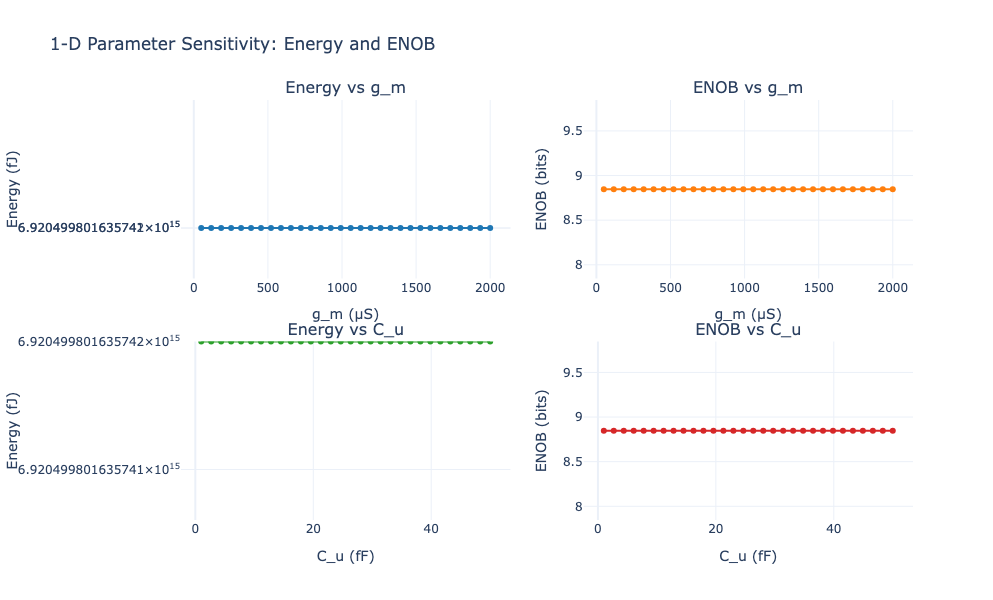

In [13]:
fig_1d = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Energy vs g_m', 'ENOB vs g_m',
        'Energy vs C_u', 'ENOB vs C_u'
    ],
    vertical_spacing=0.15,
)

fig_1d.add_trace(go.Scatter(
    x=df_gm['gm'] * 1e6, y=df_gm['energy_j'] * 1e15,
    mode='lines+markers', name='Energy vs gm',
    line=dict(color='#1f77b4', width=2),
), row=1, col=1)

fig_1d.add_trace(go.Scatter(
    x=df_gm['gm'] * 1e6, y=df_gm['enob'],
    mode='lines+markers', name='ENOB vs gm',
    line=dict(color='#ff7f0e', width=2),
), row=1, col=2)

fig_1d.add_trace(go.Scatter(
    x=df_cu['cu'] * 1e15, y=df_cu['energy_j'] * 1e15,
    mode='lines+markers', name='Energy vs Cu',
    line=dict(color='#2ca02c', width=2),
), row=2, col=1)

fig_1d.add_trace(go.Scatter(
    x=df_cu['cu'] * 1e15, y=df_cu['enob'],
    mode='lines+markers', name='ENOB vs Cu',
    line=dict(color='#d62728', width=2),
), row=2, col=2)

fig_1d.update_xaxes(title_text='g_m (µS)', row=1, col=1)
fig_1d.update_xaxes(title_text='g_m (µS)', row=1, col=2)
fig_1d.update_xaxes(title_text='C_u (fF)', row=2, col=1)
fig_1d.update_xaxes(title_text='C_u (fF)', row=2, col=2)
fig_1d.update_yaxes(title_text='Energy (fJ)', row=1, col=1)
fig_1d.update_yaxes(title_text='ENOB (bits)', row=1, col=2)
fig_1d.update_yaxes(title_text='Energy (fJ)', row=2, col=1)
fig_1d.update_yaxes(title_text='ENOB (bits)', row=2, col=2)

fig_1d.update_layout(
    title='1-D Parameter Sensitivity: Energy and ENOB',
    template='plotly_white',
    height=600, width=900,
    showlegend=False,
)
fig_1d.show()

---

## 7. Design Trade-off Discussion

From the sweeps above, we can draw several circuit-design conclusions:

### 7.1 Energy Scaling
- $E_{conv}$ scales **nearly linearly with $C_u$** (since $E_{DAC} = C_{total} V_{ref}^2 = 2^N C_u V_{ref}^2$). Every factor-of-2 reduction in $C_u$ halves the DAC energy.
- $E_{conv}$ also increases with $g_m$ via the comparator term $E_{comp} \propto g_m V_{DD} \tau N$.

### 7.2 Metastability Improvement
- The metastability dwell time $t_{meta} = \tau_{regen} \ln(V_{th}/A_{v0}|V_{res}|)$ falls **exponentially** with increasing $g_m / C_L$. Doubling $g_m$ reduces $t_{meta}$ by roughly $\tau_{regen} \ln 2 \approx 0.7 \tau_{regen}$.
- This means the metastability-energy trade-off has an **exponential-linear** character: large metastability improvements at moderate energy cost.

### 7.3 Optimal Operating Point
For a 50 MHz, 10-bit design targeting $\text{FoM}_W < 10$ fJ/conv-step:
- $C_u \approx 5$–$10$ fF (minimal matching requirement)
- $g_m \approx 500$–$1000$ µS (sufficient metastability margin)
- $C_{load} < 50$ fF (routing constraint)

The Pareto analysis confirms this region.

---

## 8. Export Sweep Data

In [14]:
csv_path = export_sweep(sweep_cu_gm, filename='sweep_cu_gm.csv')
print(f"Sweep exported → {csv_path}")

df_exported = pd.read_csv(csv_path)
print(f"Shape: {df_exported.shape}")
print(df_exported.head(3).to_string())

[NeuroSAR] Sweep exported → /Users/ayanbiswas/Documents/Development/NeuroSAR/data/exports/sweep_cu_gm.csv
Sweep exported → /Users/ayanbiswas/Documents/Development/NeuroSAR/data/exports/sweep_cu_gm.csv
Shape: (400, 6)
             cu        gm  energy_j  meta_max_s      enob    walden_fom
0  1.000000e-15  0.000050    6.9205         0.0  8.846453  3.006906e-10
1  1.000000e-15  0.000153    6.9205         0.0  8.846453  3.006906e-10
2  1.000000e-15  0.000255    6.9205         0.0  8.846453  3.006906e-10


In [15]:
# Also save the pareto front
from src.config import EXPORTS
from src.utils import ensure_dir

pareto_path = os.path.join(ensure_dir(os.path.join(PROJECT_ROOT, 'data', 'exports')),
                            'pareto_cu_gm.csv')
df_pareto.to_csv(pareto_path, index=False)
print(f"Pareto front exported → {pareto_path}")
print(f"({len(df_pareto)} Pareto-optimal design points)")

Pareto front exported → /Users/ayanbiswas/Documents/Development/NeuroSAR/data/exports/pareto_cu_gm.csv
(400 Pareto-optimal design points)


---

## 9. Summary

In this notebook we used the trained NeuroSAR PINN to execute **two 2-D parameter sweeps and two 1-D sensitivity analyses** that together would have taken hours in SPICE but completed in seconds. Key findings:

1. **Energy** scales primarily with $C_u$ (DAC term) and secondarily with $g_m$ (comparator term).
2. **Metastability** is controlled almost exclusively by $g_m / C_L$ — the ratio of transconductance to load capacitance.
3. **Pareto front** reveals the fundamental energy-metastability trade-off: further metastability reduction beyond 200 ps requires disproportionate energy investment.
4. **ENOB** is relatively insensitive to $g_m$ but degrades with large $C_{load}$ (slower settling → larger residual).

The NeuroSAR surrogate enables this kind of systematic exploration in seconds, compared to hours with SPICE.

**Next:** Open `05_Inverse_Design.ipynb` to run gradient-based optimisation and automatically find the design point that minimises metastability subject to an energy budget.